In [64]:
import plotly.express as px
import pandas as pd
import numpy as np

iris_df = pd.read_csv("iris.csv")
iris_df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [65]:
# Feature matrix (150x4)
columns = iris_df.columns 
X = iris_df[columns[:-1]].to_numpy()

# Mean vector of the 4 features
mu = np.mean(X, axis=0)
print(mu)

# Center data (subtract feature-wise mean)
X = X - mu
# or in-place: X -= mu

print(X[:5])


# Species labels
species = iris_df[columns[-1]].to_numpy()

X.shape, species.shape

[5.84333333 3.054      3.75866667 1.19866667]
[[-0.74333333  0.446      -2.35866667 -0.99866667]
 [-0.94333333 -0.054      -2.35866667 -0.99866667]
 [-1.14333333  0.146      -2.45866667 -0.99866667]
 [-1.24333333  0.046      -2.25866667 -0.99866667]
 [-0.84333333  0.546      -2.35866667 -0.99866667]]


((150, 4), (150,))

In [ ]:
import numpy as np
XT = X.transpose()
XTX = np.matmul(XT, X)

# covariance matrix
XTX = 1 / (len(X) -1) * XTX


In [67]:
# Eigen-decomposition of the symmetric 4x4 matrix XTX
eigenvalues, eigenvectors = np.linalg.eigh(XTX)

# Sort by descending eigenvalue so principal directions come first
idx = np.argsort(eigenvalues)[::-1]
W = eigenvectors[:, idx]

In [68]:
# Reduce W to the two eigenvectors with the largest eigenvalues (principal components)
Wr = W[:, :2]

T = np.dot(X, Wr)
T.shape

(150, 2)

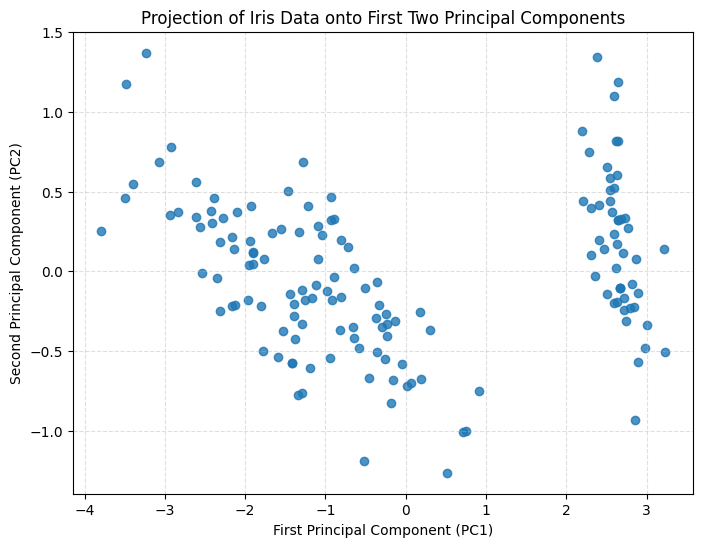

In [69]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.scatter(T[:, 0], T[:, 1], alpha=0.8)
plt.xlabel("First Principal Component (PC1)")
plt.ylabel("Second Principal Component (PC2)")
plt.title("Projection of Iris Data onto First Two Principal Components")
plt.grid(True, linestyle="--", alpha=0.4)
plt.show()

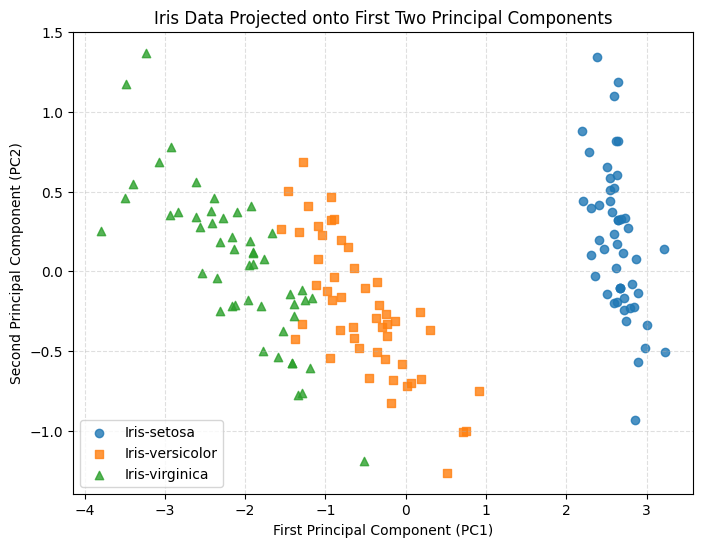

In [70]:
plt.figure(figsize=(8, 6))

markers = ['o', 's', '^']  # circle, square, triangle
for i, label in enumerate(np.unique(species)):
    mask = species == label
    plt.scatter(T[mask, 0], T[mask, 1], marker=markers[i], label=label, alpha=0.8)

plt.xlabel("First Principal Component (PC1)")
plt.ylabel("Second Principal Component (PC2)")
plt.title("Iris Data Projected onto First Two Principal Components")
plt.grid(True, linestyle="--", alpha=0.4)
plt.legend()
plt.show()

In [71]:


Wr3 = W[:, :3]
T3 = X @ Wr3

plot_df = pd.DataFrame({
    "PC1": T3[:, 0],
    "PC2": T3[:, 1],
    "PC3": T3[:, 2],
    "species": species
})

fig = px.scatter_3d(
    plot_df,
    x="PC1",
    y="PC2",
    z="PC3",
    color="species",
    title="Iris Data Projected onto First Three Principal Components",
    opacity=0.8
)

fig.show(renderer="browser")

Gtk-Message: 14:35:56.610: Not loading module "atk-bridge": The functionality is provided by GTK natively. Please try to not load it.
